# 📊 MPT Portfolio Optimizer

## Overview
This tool applies **Modern Portfolio Theory (MPT)**, first introduced by Harry Markowitz in 1952, 
to identify optimal portfolio allocations across a user-defined set of assets.

Given a set of tickers and a date range, the optimizer:
- Downloads historical price data via `yfinance`
- Computes annualised historical returns and a covariance matrix
- Runs a **Monte Carlo simulation** of 25,000 random portfolios to map the efficient frontier
- Identifies three optimal portfolios across the risk/return spectrum
- Visualizes results interactively via Plotly

## The Three Optimal Portfolios
| Portfolio | What It Optimizes | Best For |
|---|---|---|
| **Max Sharpe Ratio** | Highest return per unit of risk | Most investors |
| **Min Volatility** | Lowest possible portfolio risk | Conservative / risk-averse investors |
| **Max Return** | Highest raw historical return | Aggressive investors |

## Methodology & Limitations
- Returns are based on **annualised historical means** — not forward-looking forecasts. 
Past performance does not guarantee future results.
- The optimizer assumes **long-only positions** with no leverage or short selling.
- This tool supports **either US or Indian stocks** in a single run. Mixing both is not 
recommended as USD and INR denominated returns are not currency-adjusted.
- Monte Carlo simulation surfaces the empirical frontier but does not guarantee discovery 
of the mathematically exact optimal point. For exact optimization, convex solvers 
such as `scipy.optimize` can be used as an extension.

## Tech Stack
- `yfinance` — historical price data
- `NumPy` / `Pandas` — return and covariance calculations
- `Plotly` — interactive efficient frontier visualization

## How to Use
1. Run Cell 1 and enter your tickers when prompted
   - US stocks/ETFs: `AAPL, MSFT, GLD, SPY`
   - Indian stocks (NSE): `RELIANCE.NS, HDFCBANK.NS, INFY.NS`
2. Enter the annual risk-free rate (e.g. `5.25` for 5.25%)
3. Enter your start and end dates in `YYYY-MM-DD` format
4. Run all remaining cells sequentially
5. Hover over any point on the efficient frontier chart to inspect portfolio details

In [7]:
# ── Cell 1: Imports & Configuration ──────────────────────────────────────────

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
from datetime import datetime

# ── Disclaimer ────────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════╗
║           MPT Portfolio Optimizer — Important Notice             ║
╠══════════════════════════════════════════════════════════════════╣
║  This tool supports EITHER US stocks/ETFs OR Indian stocks.      ║
║  Do NOT mix US and Indian stocks in the same run —               ║
║  as currency differences (USD vs INR) will produce misleading    ║
║  optimization results.                                           ║
║                                                                  ║
║  How to enter tickers:                                           ║
║  • US stocks/ETFs : AAPL, MSFT, GLD, SPY                         ║
║  • Indian stocks  : RELIANCE.NS, HDFCBANK.NS, INFY.NS            ║
║    (use .NS for NSE — preferred, or .BO for BSE)                 ║
╚══════════════════════════════════════════════════════════════════╝
""")

# ── User Inputs ───────────────────────────────────────────────────────────────

TICKERS = input("Enter tickers separated by commas: ")
TICKERS = [t.strip().upper() for t in TICKERS.split(",")]

RISK_FREE_RATE = float(input("Enter the annual risk-free rate (e.g. 5.25 for 5.25%): ")) / 100

START_DATE = input("Enter start date (YYYY-MM-DD): ").strip()
END_DATE   = input("Enter end date   (YYYY-MM-DD): ").strip()

# Validate date format
try:
    START_DATE = datetime.strptime(START_DATE, "%Y-%m-%d")
    END_DATE   = datetime.strptime(END_DATE,   "%Y-%m-%d")
    assert END_DATE > START_DATE, "End date must be after start date."
except ValueError:
    print("❌ Invalid date format. Please use YYYY-MM-DD (e.g. 2022-01-01)")
except AssertionError as e:
    print(f"❌ {e}")

NUM_PORTFOLIOS = 25_000

print(f"\n✅ Config set.")
print(f"   Tickers        : {TICKERS}")
print(f"   Risk-free rate : {RISK_FREE_RATE:.2%}")
print(f"   Period         : {START_DATE.strftime('%Y-%m-%d')} → {END_DATE.strftime('%Y-%m-%d')}")


╔══════════════════════════════════════════════════════════════════╗
║           MPT Portfolio Optimizer — Important Notice             ║
╠══════════════════════════════════════════════════════════════════╣
║  This tool supports EITHER US stocks/ETFs OR Indian stocks.      ║
║  Do NOT mix US and Indian stocks in the same run —               ║
║  as currency differences (USD vs INR) will produce misleading    ║
║  optimization results.                                           ║
║                                                                  ║
║  How to enter tickers:                                           ║
║  • US stocks/ETFs : AAPL, MSFT, GLD, SPY                         ║
║  • Indian stocks  : RELIANCE.NS, HDFCBANK.NS, INFY.NS            ║
║    (use .NS for NSE — preferred, or .BO for BSE)                 ║
╚══════════════════════════════════════════════════════════════════╝



Enter tickers separated by commas:  ADBE,AIPO,AIQ,AMD,AMZN,BABA,BOTZ,BRK-B,CIBR,DTCR
Enter the annual risk-free rate (e.g. 5.25 for 5.25%):  4.5
Enter start date (YYYY-MM-DD):  2022-01-01
Enter end date   (YYYY-MM-DD):  2026-03-31



✅ Config set.
   Tickers        : ['ADBE', 'AIPO', 'AIQ', 'AMD', 'AMZN', 'BABA', 'BOTZ', 'BRK-B', 'CIBR', 'DTCR']
   Risk-free rate : 4.50%
   Period         : 2022-01-01 → 2026-03-31


## Cell 1 — Imports & Configuration

This cell sets up everything needed before any analysis begins.

### Libraries imported:
- **`numpy`** — numerical operations, especially for matrix math used in portfolio variance calculations
- **`pandas`** — tabular data handling for price history and returns
- **`yfinance`** — fetches historical OHLCV data from Yahoo Finance for any given ticker and date range
- **`plotly.graph_objects`** — builds interactive charts (used later for the Efficient Frontier plot)
- **`datetime`** — parses and validates the user-supplied date strings

### User inputs collected:
| Input | Description |
|---|---|
| `TICKERS` | Comma-separated stock symbols, uppercased and stripped of whitespace |
| `RISK_FREE_RATE` | The annual yield of a "zero-risk" asset (e.g. a T-bill), used to compute the Sharpe Ratio |
| `START_DATE` / `END_DATE` | The historical window over which returns are calculated |

### Date validation:
Both dates are parsed with `datetime.strptime()` to enforce the `YYYY-MM-DD` format. An `assert` statement also guarantees that the end date is strictly after the start date — catching logical errors before any data is downloaded.

### `NUM_PORTFOLIOS = 25_000`
This sets how many random weight combinations will be simulated in the Monte Carlo step later. A higher number gives a smoother, more accurate Efficient Frontier curve but takes longer to compute.

In [8]:
# ── Cell 2: Download Price Data & Calculate Daily Returns ─────────────────────

print("⏳ Downloading price data...")

# Download adjusted closing prices for all tickers
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=False)

# Extract only the 'Close' prices
prices = raw_data["Adj Close"]

# Drop any dates where ANY ticker has missing data
prices = prices.dropna()

# Calculate daily percentage returns
returns = prices.pct_change().dropna()

print(f"\n✅ Data downloaded successfully.")
print(f"   Tickers        : {list(returns.columns)}")
print(f"   Trading days   : {len(returns)}")
print(f"   Date range     : {returns.index[0].strftime('%Y-%m-%d')} → {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"\n── Daily Returns Preview (first 5 rows) ──")
print(returns.head())

⏳ Downloading price data...


[*********************100%***********************]  10 of 10 completed


✅ Data downloaded successfully.
   Tickers        : ['ADBE', 'AIPO', 'AIQ', 'AMD', 'AMZN', 'BABA', 'BOTZ', 'BRK-B', 'CIBR', 'DTCR']
   Trading days   : 170
   Date range     : 2025-07-28 → 2026-03-30

── Daily Returns Preview (first 5 rows) ──
Ticker          ADBE      AIPO       AIQ       AMD      AMZN      BABA  \
Date                                                                     
2025-07-28 -0.003426  0.001376  0.004247  0.043191  0.005833  0.017662   
2025-07-29  0.003329 -0.004808 -0.001113  0.021767 -0.007646 -0.022841   
2025-07-30 -0.018074  0.016612 -0.001337  0.011666 -0.003550 -0.016588   
2025-07-31 -0.017335 -0.002085 -0.005578 -0.017826  0.017029  0.027688   
2025-08-01 -0.027650 -0.020360 -0.024680 -0.026147 -0.082696 -0.029512   

Ticker          BOTZ     BRK-B      CIBR      DTCR  
Date                                                
2025-07-28 -0.002039 -0.004896 -0.004688 -0.007180  
2025-07-29 -0.011675 -0.010671  0.002153 -0.005682  
2025-07-30 -0.004725 -0.

## Cell 2 — Download Price Data & Calculate Daily Returns

Before any portfolio math can happen, we need **clean historical return data** for every ticker. This cell handles the full pipeline: downloading → extracting → cleaning → transforming.

---

### Step-by-step breakdown:

**1. Downloading price data with `yf.download()`**
```python
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=False)
```
This fetches a full OHLCV (Open, High, Low, Close, Volume) table from Yahoo Finance for all tickers at once. `auto_adjust=False` is set explicitly so we can manually extract **Adjusted Close** prices ourselves, which account for stock splits and dividend distributions — giving a more accurate picture of true investor returns.

---

**2. Extracting Adjusted Close prices**
```python
prices = raw_data["Adj Close"]
```
From the full multi-column download, we isolate only the `Adj Close` column. This gives us a clean DataFrame where:
- Each **row** = one trading day
- Each **column** = one ticker's adjusted closing price

---

**3. Dropping missing data**
```python
prices = prices.dropna()
```
Some tickers may have missing values on certain dates (e.g. a stock was not yet listed, or had a trading halt). `.dropna()` removes any row where **at least one ticker** has a missing value, ensuring all tickers share the exact same set of trading days. This is critical — portfolio math requires aligned, complete data across all assets.

---

**4. Calculating daily returns**
```python
returns = prices.pct_change().dropna()
```
Raw prices are not directly useful for MPT — we need **returns**. `.pct_change()` computes the day-over-day percentage change for each ticker:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

The first row becomes `NaN` (no previous day to compare against), so `.dropna()` removes it.

> 💡 **Why returns and not prices?** Returns are stationary, comparable across assets regardless of price scale, and directly map to the gain/loss an investor experiences — all of which are assumptions MPT relies on.

In [9]:
# ── Cell 3: Compute Expected Returns & Covariance Matrix ─────────────────────

# Annualize daily returns (252 trading days in a year)
mean_returns = returns.mean() * 252

# Annualize the covariance matrix
cov_matrix = returns.cov() * 252

print("✅ Statistics computed.")
print(f"\n── Annualized Historical Returns ──")
for ticker, ret in mean_returns.items():
    print(f"   {ticker}: {ret:.2%}")

print(f"\n── Annualized Covariance Matrix ──")
print(cov_matrix.round(6))

✅ Statistics computed.

── Annualized Historical Returns ──
   ADBE: -58.70%
   AIPO: 29.11%
   AIQ: 2.77%
   AMD: 44.24%
   AMZN: -15.91%
   BABA: 12.52%
   BOTZ: -7.22%
   BRK-B: -1.74%
   CIBR: -27.50%
   DTCR: 28.29%

── Annualized Covariance Matrix ──
Ticker      ADBE      AIPO       AIQ       AMD      AMZN      BABA      BOTZ  \
Ticker                                                                         
ADBE    0.099104 -0.018606  0.015039 -0.008990  0.031252 -0.000386  0.011709   
AIPO   -0.018606  0.113501  0.057623  0.131900  0.030840  0.040626  0.054282   
AIQ     0.015039  0.057623  0.050288  0.087561  0.039229  0.044344  0.041323   
AMD    -0.008990  0.131900  0.087561  0.410180  0.048014  0.067013  0.069260   
AMZN    0.031252  0.030840  0.039229  0.048014  0.100928  0.021627  0.028954   
BABA   -0.000386  0.040626  0.044344  0.067013  0.021627  0.207211  0.034684   
BOTZ    0.011709  0.054282  0.041323  0.069260  0.028954  0.034684  0.052358   
BRK-B   0.011433 -0.010

## Cell 3 — Compute Expected Returns & Covariance Matrix

This cell computes the two **core statistical inputs** that every MPT calculation depends on — the expected return of each asset, and how all assets move relative to one another. Everything from the Efficient Frontier to the Sharpe Ratio is built on top of these two numbers.

---

### Step-by-step breakdown:

**1. Annualized Expected Returns**
```python
mean_returns = returns.mean() * 252
```
We take the **average daily return** for each ticker and scale it up to an annual figure by multiplying by 252 — the standard number of trading days in a calendar year.

$$\mu_i = \bar{r}_i \times 252$$

This gives us a single number per ticker representing its **expected annual return** based on historical performance. For example, a mean daily return of 0.05% becomes an annualized return of ~12.6%.

> 💡 **Why 252 and not 365?** Stock markets are closed on weekends and public holidays. 252 is the widely accepted convention for the number of actual trading days per year.

---

**2. Annualized Covariance Matrix**
```python
cov_matrix = returns.cov() * 252
```
The covariance matrix captures how every pair of assets moves **relative to each other** over time. Multiplying by 252 annualizes it, consistent with the return scaling above.

For a portfolio of *n* assets, this produces an *n × n* matrix where:

- **Diagonal entries** → each asset's own annualized variance (how volatile it is individually)
- **Off-diagonal entries** → the covariance between each pair of assets (do they tend to move together or independently?)

$$\Sigma_{ij} = \text{Cov}(r_i,\ r_j) \times 252$$

This matrix is the engine behind **diversification**. Two assets with low or negative covariance reduce overall portfolio risk when held together — even if each is individually volatile.

> 💡 **Covariance vs Correlation:** Covariance is in raw return units and harder to interpret on its own. Correlation (covariance normalized between -1 and +1) is more intuitive, but MPT uses the covariance matrix directly because portfolio variance calculations require it in its raw form:
> $$\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$$
> where **w** is the vector of portfolio weights.

In [10]:
# ── Cell 4: Monte Carlo Simulation ───────────────────────────────────────────
n_assets = len(TICKERS)

# Arrays to store results
port_returns    = np.zeros(NUM_PORTFOLIOS)
port_volatility = np.zeros(NUM_PORTFOLIOS)
port_sharpe     = np.zeros(NUM_PORTFOLIOS)
port_weights    = np.zeros((NUM_PORTFOLIOS, n_assets))

print(f"⏳ Simulating {NUM_PORTFOLIOS:,} random portfolios...")

for i in range(NUM_PORTFOLIOS):

    # Step 1: Generate random weights that sum to 1
    weights = np.random.random(n_assets)
    weights = weights / weights.sum()

    # Step 2: Portfolio annualized return
    p_return = np.dot(weights, mean_returns)

    # Step 3: Portfolio annualized volatility
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Step 4: Sharpe ratio
    p_sharpe = (p_return - RISK_FREE_RATE) / p_volatility

    # Store results
    port_returns[i]    = p_return
    port_volatility[i] = p_volatility
    port_sharpe[i]     = p_sharpe
    port_weights[i]    = weights

print(f"✅ Simulation complete.")
print(f"\n── Simulation Summary (across {NUM_PORTFOLIOS:,} portfolios) ──")
print(f"   Return     — Min: {port_returns.min():.2%}  |  Max: {port_returns.max():.2%}  |  Avg: {port_returns.mean():.2%}")
print(f"   Volatility — Min: {port_volatility.min():.2%}  |  Max: {port_volatility.max():.2%}  |  Avg: {port_volatility.mean():.2%}")
print(f"   Sharpe     — Min: {port_sharpe.min():.4f}  |  Max: {port_sharpe.max():.4f}  |  Avg: {port_sharpe.mean():.4f}")

⏳ Simulating 25,000 random portfolios...
✅ Simulation complete.

── Simulation Summary (across 25,000 portfolios) ──
   Return     — Min: -29.35%  |  Max: 23.01%  |  Avg: 0.56%
   Volatility — Min: 13.33%  |  Max: 30.52%  |  Avg: 19.91%
   Sharpe     — Min: -1.6483  |  Max: 0.6471  |  Avg: -0.2190


## Cell 4 — Monte Carlo Simulation

Now that we have our expected returns and covariance matrix, we use a **Monte Carlo simulation** to explore the universe of possible portfolios. Instead of mathematically solving for every possible combination (which is computationally expensive), we randomly sample 10,000 different weight combinations and compute the risk-return profile of each one.

The cloud of points this produces is what ultimately reveals the shape of the **Efficient Frontier**.

---

### Step-by-step breakdown:

**1. Pre-allocating result arrays**
```python
port_returns    = np.zeros(NUM_PORTFOLIOS)
port_volatility = np.zeros(NUM_PORTFOLIOS)
port_sharpe     = np.zeros(NUM_PORTFOLIOS)
port_weights    = np.zeros((NUM_PORTFOLIOS, n_assets))
```
Before the loop, we create empty arrays to store each portfolio's results. Pre-allocating with `np.zeros()` is significantly faster than appending to a list on every iteration, since NumPy reserves the memory upfront.

---

**2. The simulation loop**

Each of the 10,000 iterations does four things:

**Step 1 — Random weights that sum to 1**
```python
weights = np.random.random(n_assets)
weights = weights / weights.sum()
```
We generate *n* random numbers (one per asset) and normalize them by dividing by their sum. This guarantees the weights always add up to exactly 1 (i.e. 100% of the portfolio is allocated), representing a standard **long-only portfolio** with no leverage or short selling.

---

**Step 2 — Portfolio annualized return**
```python
p_return = np.dot(weights, mean_returns)
```
The expected portfolio return is simply the **weighted average** of individual asset returns:

$$\mu_p = \mathbf{w}^T \boldsymbol{\mu} = \sum_{i=1}^{n} w_i \mu_i$$

`np.dot()` computes this in one efficient operation.

---

**Step 3 — Portfolio annualized volatility**
```python
p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
```
Portfolio volatility is **not** a simple weighted average — it accounts for how assets co-move via the covariance matrix:

$$\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$$

This is the key insight of MPT: combining assets with low covariance reduces overall portfolio volatility below the weighted average of individual volatilities. That reduction is the mathematical definition of **diversification**.

---

**Step 4 — Sharpe Ratio**
```python
p_sharpe = (p_return - RISK_FREE_RATE) / p_volatility
```
The Sharpe Ratio measures **return earned per unit of risk taken**, above and beyond the risk-free rate:

$$S = \frac{\mu_p - r_f}{\sigma_p}$$

A higher Sharpe Ratio means better risk-adjusted performance. The portfolio with the highest Sharpe Ratio across all 10,000 simulations is the **Maximum Sharpe Portfolio** — the most efficient portfolio in the entire simulated universe.

---

### Why Monte Carlo and not an exact solver?

An exact optimizer (e.g. `scipy.optimize`) would find the *mathematically perfect* efficient frontier. Monte Carlo is used here because:
- It is **intuitive and visual** — you can literally see the frontier emerge from the cloud of points
- It requires **no additional dependencies** beyond NumPy
- With 10,000 samples it gets close enough for educational and practical exploratory purposes

> 💡 The simulation summary printed at the end gives a sanity check — the spread of return, volatility, and Sharpe values across all 10,000 portfolios tells you how wide the opportunity set is for your chosen set of tickers.

In [11]:
# ── Cell 5: Identify Optimal Portfolios ──────────────────────────────────────

# Max Sharpe Ratio portfolio
max_sharpe_idx = np.argmax(port_sharpe)
max_sharpe_return     = port_returns[max_sharpe_idx]
max_sharpe_volatility = port_volatility[max_sharpe_idx]
max_sharpe_ratio      = port_sharpe[max_sharpe_idx]
max_sharpe_weights    = port_weights[max_sharpe_idx]

# Minimum Volatility portfolio
min_vol_idx = np.argmin(port_volatility)
min_vol_return     = port_returns[min_vol_idx]
min_vol_volatility = port_volatility[min_vol_idx]
min_vol_sharpe     = port_sharpe[min_vol_idx]
min_vol_weights    = port_weights[min_vol_idx]

# Maximum Return portfolio
max_return_idx        = np.argmax(port_returns)
max_return_return     = port_returns[max_return_idx]
max_return_volatility = port_volatility[max_return_idx]
max_return_sharpe     = port_sharpe[max_return_idx]
max_return_weights    = port_weights[max_return_idx]

# ── Print Results ─────────────────────────────────────────────────────────────

print("✅ Optimal portfolios identified.")

print(f"\n── Maximum Sharpe Ratio Portfolio ──")
print(f"   Sharpe Ratio : {max_sharpe_ratio:.4f}")
print(f"   Return       : {max_sharpe_return:.2%}")
print(f"   Volatility   : {max_sharpe_volatility:.2%}")
print(f"\n   Weights:")
for t, w in zip(TICKERS, max_sharpe_weights):
    print(f"      {t}: {w:.2%}")

print(f"\n── Minimum Volatility Portfolio ──")
print(f"   Sharpe Ratio : {min_vol_sharpe:.4f}")
print(f"   Return       : {min_vol_return:.2%}")
print(f"   Volatility   : {min_vol_volatility:.2%}")
print(f"\n   Weights:")
for t, w in zip(TICKERS, min_vol_weights):
    print(f"      {t}: {w:.2%}")

print(f"\n── Maximum Return Portfolio ──")
print(f"   Sharpe Ratio : {max_return_sharpe:.4f}")
print(f"   Return       : {max_return_return:.2%}")
print(f"   Volatility   : {max_return_volatility:.2%}")
print(f"\n   Weights:")
for t, w in zip(TICKERS, max_return_weights):
    print(f"      {t}: {w:.2%}")
print(f"\n   ⚠️  Note: Max return portfolios typically concentrate in a")
print(f"   single asset — return is maximized but diversification is sacrificed.")

✅ Optimal portfolios identified.

── Maximum Sharpe Ratio Portfolio ──
   Sharpe Ratio : 0.6471
   Return       : 23.01%
   Volatility   : 28.60%

   Weights:
      ADBE: 1.56%
      AIPO: 23.88%
      AIQ: 0.49%
      AMD: 21.69%
      AMZN: 5.91%
      BABA: 22.51%
      BOTZ: 0.57%
      BRK-B: 3.44%
      CIBR: 0.11%
      DTCR: 19.85%

── Minimum Volatility Portfolio ──
   Sharpe Ratio : -0.5405
   Return       : -2.71%
   Volatility   : 13.33%

   Weights:
      ADBE: 3.68%
      AIPO: 0.09%
      AIQ: 1.83%
      AMD: 2.25%
      AMZN: 8.25%
      BABA: 0.35%
      BOTZ: 20.18%
      BRK-B: 33.37%
      CIBR: 12.19%
      DTCR: 17.80%

── Maximum Return Portfolio ──
   Sharpe Ratio : 0.6471
   Return       : 23.01%
   Volatility   : 28.60%

   Weights:
      ADBE: 1.56%
      AIPO: 23.88%
      AIQ: 0.49%
      AMD: 21.69%
      AMZN: 5.91%
      BABA: 22.51%
      BOTZ: 0.57%
      BRK-B: 3.44%
      CIBR: 0.11%
      DTCR: 19.85%

   ⚠️  Note: Max return portfolios typically c

## Cell 5 — Identify Optimal Portfolios

From the 10,000 simulated portfolios, this cell **pinpoints three special portfolios** that represent distinct investment philosophies. Each is optimal in a different sense — the right choice depends entirely on an investor's goals and risk tolerance.

---

### The three optimal portfolios:

---

**1. 🟡 Maximum Sharpe Ratio Portfolio**
```python
max_sharpe_idx = np.argmax(port_sharpe)
```
Found by locating the index of the highest Sharpe Ratio across all simulations using `np.argmax()`.

This is widely considered the **"best" portfolio under MPT** — it delivers the highest return per unit of risk taken. On the Efficient Frontier plot (next cell), this is the point where a line drawn from the risk-free rate is *tangent* to the frontier curve, which is why it is also called the **Tangency Portfolio**.

> 📌 **Best for:** Investors who want the most efficient risk-reward tradeoff — neither unnecessarily aggressive nor unnecessarily conservative.

---

**2. 🟢 Minimum Volatility Portfolio**
```python
min_vol_idx = np.argmin(port_volatility)
```
Found by locating the index of the lowest volatility across all simulations using `np.argmin()`.

This portfolio minimizes overall portfolio fluctuation regardless of return. It sits at the **leftmost tip** of the Efficient Frontier — the point where taking on any less risk is mathematically impossible given the chosen set of assets.

> 📌 **Best for:** Risk-averse investors — retirees, capital preservation strategies, or anyone who prioritizes stability over growth.

---

**3. 🔴 Maximum Return Portfolio**
```python
max_return_idx = np.argmax(port_returns)
```
Found by locating the index of the highest return across all simulations using `np.argmax()`.

This portfolio chases the highest possible return with no regard for risk. In practice, it almost always concentrates the **entire allocation into a single asset** — whichever ticker had the highest historical return over the chosen period. It sits at the **top-right tip** of the Efficient Frontier.

> ⚠️ **Important caveat:** Maximum return portfolios are not truly "optimal" in the MPT sense — they sacrifice all diversification benefit. They are included here for completeness and as a reference point, not as a recommendation.

---

### Why only these three?

These three portfolios are the **anchor points** of the Efficient Frontier:

| Portfolio | Position on Frontier | Optimizes |
|---|---|---|
| Max Sharpe | Middle curve | Risk-adjusted return |
| Min Volatility | Leftmost tip | Safety |
| Max Return | Topmost tip | Raw return |

Every other point on the frontier is a valid portfolio too — they simply represent different tradeoffs between the Min Volatility and Max Return extremes. An investor can choose any point on the frontier depending on how much volatility they are personally comfortable accepting.

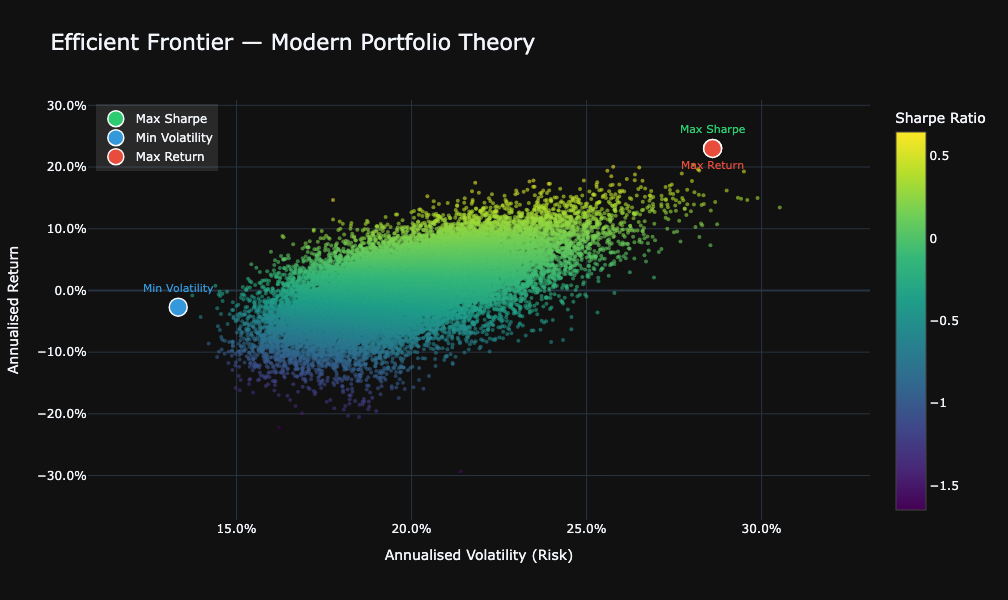

In [20]:
# ── Cell 6: Plotly Visualization ─────────────────────────────────────────────

import plotly.graph_objects as go

fig = go.Figure()

# ── Scatter: All simulated portfolios coloured by Sharpe ratio ────────────────
fig.add_trace(go.Scatter(
    x=port_volatility,
    y=port_returns,
    mode="markers",
    marker=dict(
        size=4,
        color=port_sharpe,
        colorscale="Viridis",
        colorbar=dict(title="Sharpe Ratio"),
        opacity=0.6
    ),
    text=[
        f"Return: {r:.2%}<br>Volatility: {v:.2%}<br>Sharpe: {s:.4f}"
        for r, v, s in zip(port_returns, port_volatility, port_sharpe)
    ],
    hoverinfo="text",
    name="Simulated Portfolios",
    showlegend=False
))

# ── Max Sharpe portfolio ───────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=[max_sharpe_volatility],
    y=[max_sharpe_return],
    mode="markers+text",
    marker=dict(size=18, color="#2ECC71", symbol="circle", line=dict(color="white", width=1.5)),
    text=["Max Sharpe"],
    textposition="top center",
    textfont=dict(color="#2ECC71", size=11),
    customdata=[[max_sharpe_return, max_sharpe_volatility, max_sharpe_ratio] + list(max_sharpe_weights)],
    hovertext=[f"<b>Max Sharpe</b><br>Return: {max_sharpe_return:.2%}<br>"
               f"Volatility: {max_sharpe_volatility:.2%}<br>Sharpe: {max_sharpe_ratio:.4f}<br><br>"
               f"Weights:<br>" + "<br>".join([f"{t}: {w:.2%}" for t, w in zip(TICKERS, max_sharpe_weights)])],
    hoverinfo="text",
    name="Max Sharpe"
))

# ── Min Volatility portfolio ───────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=[min_vol_volatility],
    y=[min_vol_return],
    mode="markers+text",
    marker=dict(size=18, color="#3498DB", symbol="circle", line=dict(color="white", width=1.5)),
    text=["Min Volatility"],
    textposition="top center",
    textfont=dict(color="#3498DB", size=11),
    hovertext=[f"<b>Min Volatility</b><br>Return: {min_vol_return:.2%}<br>"
               f"Volatility: {min_vol_volatility:.2%}<br>Sharpe: {min_vol_sharpe:.4f}<br><br>"
               f"Weights:<br>" + "<br>".join([f"{t}: {w:.2%}" for t, w in zip(TICKERS, min_vol_weights)])],
    hoverinfo="text",
    name="Min Volatility"
))

# ── Max Return portfolio ───────────────────────────────────────────────────────
fig.add_trace(go.Scatter(
    x=[max_return_volatility],
    y=[max_return_return],
    mode="markers+text",
    marker=dict(size=18, color="#E74C3C", symbol="circle", line=dict(color="white", width=1.5)),
    text=["Max Return"],
    textposition="bottom center",
    textfont=dict(color="#E74C3C", size=11),
    hovertext=[f"<b>Max Return</b><br>Return: {max_return_return:.2%}<br>"
               f"Volatility: {max_return_volatility:.2%}<br>Sharpe: {max_return_sharpe:.4f}<br><br>"
               f"Weights:<br>" + "<br>".join([f"{t}: {w:.2%}" for t, w in zip(TICKERS, max_return_weights)])],
    hoverinfo="text",
    name="Max Return"
))

# ── Layout ────────────────────────────────────────────────────────────────────
# ── Calculate axis ranges BEFORE update_layout ────────────────────────────────
y_min = min(float(port_returns.min()), float(min_vol_return), float(max_sharpe_return), float(max_return_return))
y_max = max(float(port_returns.max()), float(min_vol_return), float(max_sharpe_return), float(max_return_return))
y_padding = (y_max - y_min) * 0.15

x_min = min(float(port_volatility.min()), float(min_vol_volatility), float(max_sharpe_volatility), float(max_return_volatility))
x_max = max(float(port_volatility.max()), float(min_vol_volatility), float(max_sharpe_volatility), float(max_return_volatility))
x_padding = (x_max - x_min) * 0.15

fig.update_layout(
    title=dict(
        text="Efficient Frontier — Modern Portfolio Theory",
        font=dict(size=22)
    ),
    xaxis=dict(
        title="Annualised Volatility (Risk)",
        tickformat=".1%",
        fixedrange=True,
        range=[x_min - x_padding, x_max + x_padding]
    ),
    yaxis=dict(
        title="Annualised Return",
        tickformat=".1%",
        fixedrange=True,
        range=[y_min - y_padding, y_max + y_padding]
    ),
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.1)"),
    hovermode="closest",
    width=900,
    height=600,
    template="plotly_dark"
)

## Cell 6 — Efficient Frontier Visualization

This cell brings everything together into an **interactive Plotly chart** — the Efficient Frontier plot. Every concept from the previous cells (simulated portfolios, risk, return, Sharpe Ratio, and the three optimal portfolios) is visualized here in one unified diagram.

---

### What you see on the chart:

**The scatter cloud — all 10,000 simulated portfolios**
Each dot represents one randomly weighted portfolio from the Monte Carlo simulation. The dots are coloured by **Sharpe Ratio** using the `Viridis` colorscale — purple/dark = low Sharpe, yellow/bright = high Sharpe. The curved upper-left boundary that naturally emerges from this cloud *is* the Efficient Frontier — every portfolio below and to the right of it is suboptimal (same risk, less return, or same return, more risk).

**The three landmark markers:**

| Marker | Colour | Meaning |
|---|---|---|
| 🟢 Max Sharpe | Green | Best risk-adjusted return — the Tangency Portfolio |
| 🔵 Min Volatility | Blue | Lowest possible risk — leftmost tip of the frontier |
| 🔴 Max Return | Red | Highest raw return — topmost tip, usually undiversified |

Hovering over **any dot** shows its exact return, volatility, and Sharpe Ratio. Hovering over the **three landmark markers** additionally shows the full asset weight breakdown for that portfolio.

---

### Code structure breakdown:

**1. Building each trace with `fig.add_trace()`**

Plotly builds charts by layering independent **traces** on top of each other. This chart has four:
- One `go.Scatter` for all 10,000 portfolio dots (coloured by Sharpe via `colorscale="Viridis"`)
- Three individual `go.Scatter` traces for the Max Sharpe, Min Volatility, and Max Return portfolios

Each landmark marker uses `size=18` to stand out clearly against the smaller `size=4` simulation dots, and a black border (`line=dict(color="black", width=1)`) for contrast against the dark background.

**2. Hover tooltips**
```python
text=[f"Return: {r:.2%}<br>Volatility: {v:.2%}<br>Sharpe: {s:.4f}" ...]
hoverinfo="text"
```
Each point carries a pre-formatted HTML string as its hover label. `<br>` acts as a line break inside the tooltip. For the landmark portfolios, a list comprehension dynamically appends the full weight breakdown for every ticker, so the tooltip updates automatically regardless of how many assets are in the portfolio.

**3. Chart layout**
```python
fig.update_layout(...)
```
- Axes are formatted as percentages with `tickformat=".1%"` for readability
- `template="plotly_dark"` applies a dark background theme, which makes the Viridis colorscale pop visually
- `hovermode="closest"` ensures the tooltip always snaps to the nearest single point rather than showing multiple
- `scrollZoom=False` in the config prevents accidental zooming when scrolling past the chart in the notebook

> 💡 **Reading the chart:** Any portfolio that lies *on* the upper-left boundary of the cloud is considered "efficient" — you cannot get more return for that level of risk, or less risk for that level of return. Any portfolio *inside* the cloud is inefficient by definition. A rational investor should always prefer a portfolio on the frontier.

In [21]:
# ── Cell 7: Optimal Portfolio Weights Summary ─────────────────────────────────

summary_data = {
    "Ticker": TICKERS,
    "Max Sharpe Weight": [f"{w:.2%}" for w in max_sharpe_weights],
    "Min Volatility Weight": [f"{w:.2%}" for w in min_vol_weights],
    "Max Return Weight": [f"{w:.2%}" for w in max_return_weights]
}

summary_df = pd.DataFrame(summary_data)

metrics_data = {
    "Metric": ["Annualised Return", "Annualised Volatility", "Sharpe Ratio"],
    "Max Sharpe": [f"{max_sharpe_return:.2%}", f"{max_sharpe_volatility:.2%}", f"{max_sharpe_ratio:.4f}"],
    "Min Volatility": [f"{min_vol_return:.2%}", f"{min_vol_volatility:.2%}", f"{min_vol_sharpe:.4f}"],
    "Max Return": [f"{max_return_return:.2%}", f"{max_return_volatility:.2%}", f"{max_return_sharpe:.4f}"]
}

metrics_df = pd.DataFrame(metrics_data)

print("── Optimal Portfolio Weights ──")
print(summary_df.to_string(index=False))
print(f"\n── Portfolio Metrics ──")
print(metrics_df.to_string(index=False))

── Optimal Portfolio Weights ──
Ticker Max Sharpe Weight Min Volatility Weight Max Return Weight
  ADBE             1.56%                 3.68%             1.56%
  AIPO            23.88%                 0.09%            23.88%
   AIQ             0.49%                 1.83%             0.49%
   AMD            21.69%                 2.25%            21.69%
  AMZN             5.91%                 8.25%             5.91%
  BABA            22.51%                 0.35%            22.51%
  BOTZ             0.57%                20.18%             0.57%
 BRK-B             3.44%                33.37%             3.44%
  CIBR             0.11%                12.19%             0.11%
  DTCR            19.85%                17.80%            19.85%

── Portfolio Metrics ──
               Metric Max Sharpe Min Volatility Max Return
    Annualised Return     23.01%         -2.71%     23.01%
Annualised Volatility     28.60%         13.33%     28.60%
         Sharpe Ratio     0.6471        -0.5405    

## Cell 7 — Optimal Portfolio Weights Summary

This final cell produces a clean, **side-by-side tabular summary** of all three optimal portfolios — both their asset allocations and their performance metrics. While the Plotly chart in Cell 6 is great for visual exploration, this table is what you would actually use to **act on the results** — knowing exactly how much of your capital to allocate to each asset.

---

### Two tables are produced:

**1. Portfolio Weights Table (`summary_df`)**
```python
summary_data = {
    "Ticker": TICKERS,
    "Max Sharpe Weight": ...,
    "Min Volatility Weight": ...,
    "Max Return Weight": ...
}
```
Each row is one ticker. Each column is one of the three optimal portfolios. The weights are formatted as percentages with `f"{w:.2%}"` for readability. This directly answers the practical question: *"If I want portfolio X, how much do I put in each stock?"*

---

**2. Portfolio Metrics Table (`metrics_df`)**
```python
metrics_data = {
    "Metric": ["Annualised Return", "Annualised Volatility", "Sharpe Ratio"],
    "Max Sharpe": [...],
    "Min Volatility": [...],
    "Max Return": [...]
}
```
Each row is one performance metric. Each column is one of the three optimal portfolios. This lets you directly compare the three portfolios on the same scale — making the tradeoffs explicit at a glance.

---

### Why `to_string(index=False)`?
```python
print(summary_df.to_string(index=False))
```
By default, pandas prints a numeric row index (0, 1, 2...) alongside every DataFrame. Since the `Ticker` column already acts as a natural row identifier, `index=False` suppresses the redundant numeric index and keeps the output clean.

---

### How to read the results together:

| Question | Look at |
|---|---|
| Which portfolio is most efficient overall? | Highest Sharpe Ratio in the metrics table |
| Which portfolio is safest? | Lowest Volatility in the metrics table |
| How do I actually build portfolio X? | That portfolio's weight column in the weights table |
| Is diversification happening? | Check if weights are spread across assets vs concentrated in one |

💡 **Tip for real-world use:** The Max Sharpe weights from this table are your starting allocation. In practice you would periodically **rebalance** — recalculating these weights on a rolling window of fresh data (e.g. every quarter) as market conditions change, since historical weights do not remain optimal indefinitely.